In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.ticker import MultipleLocator

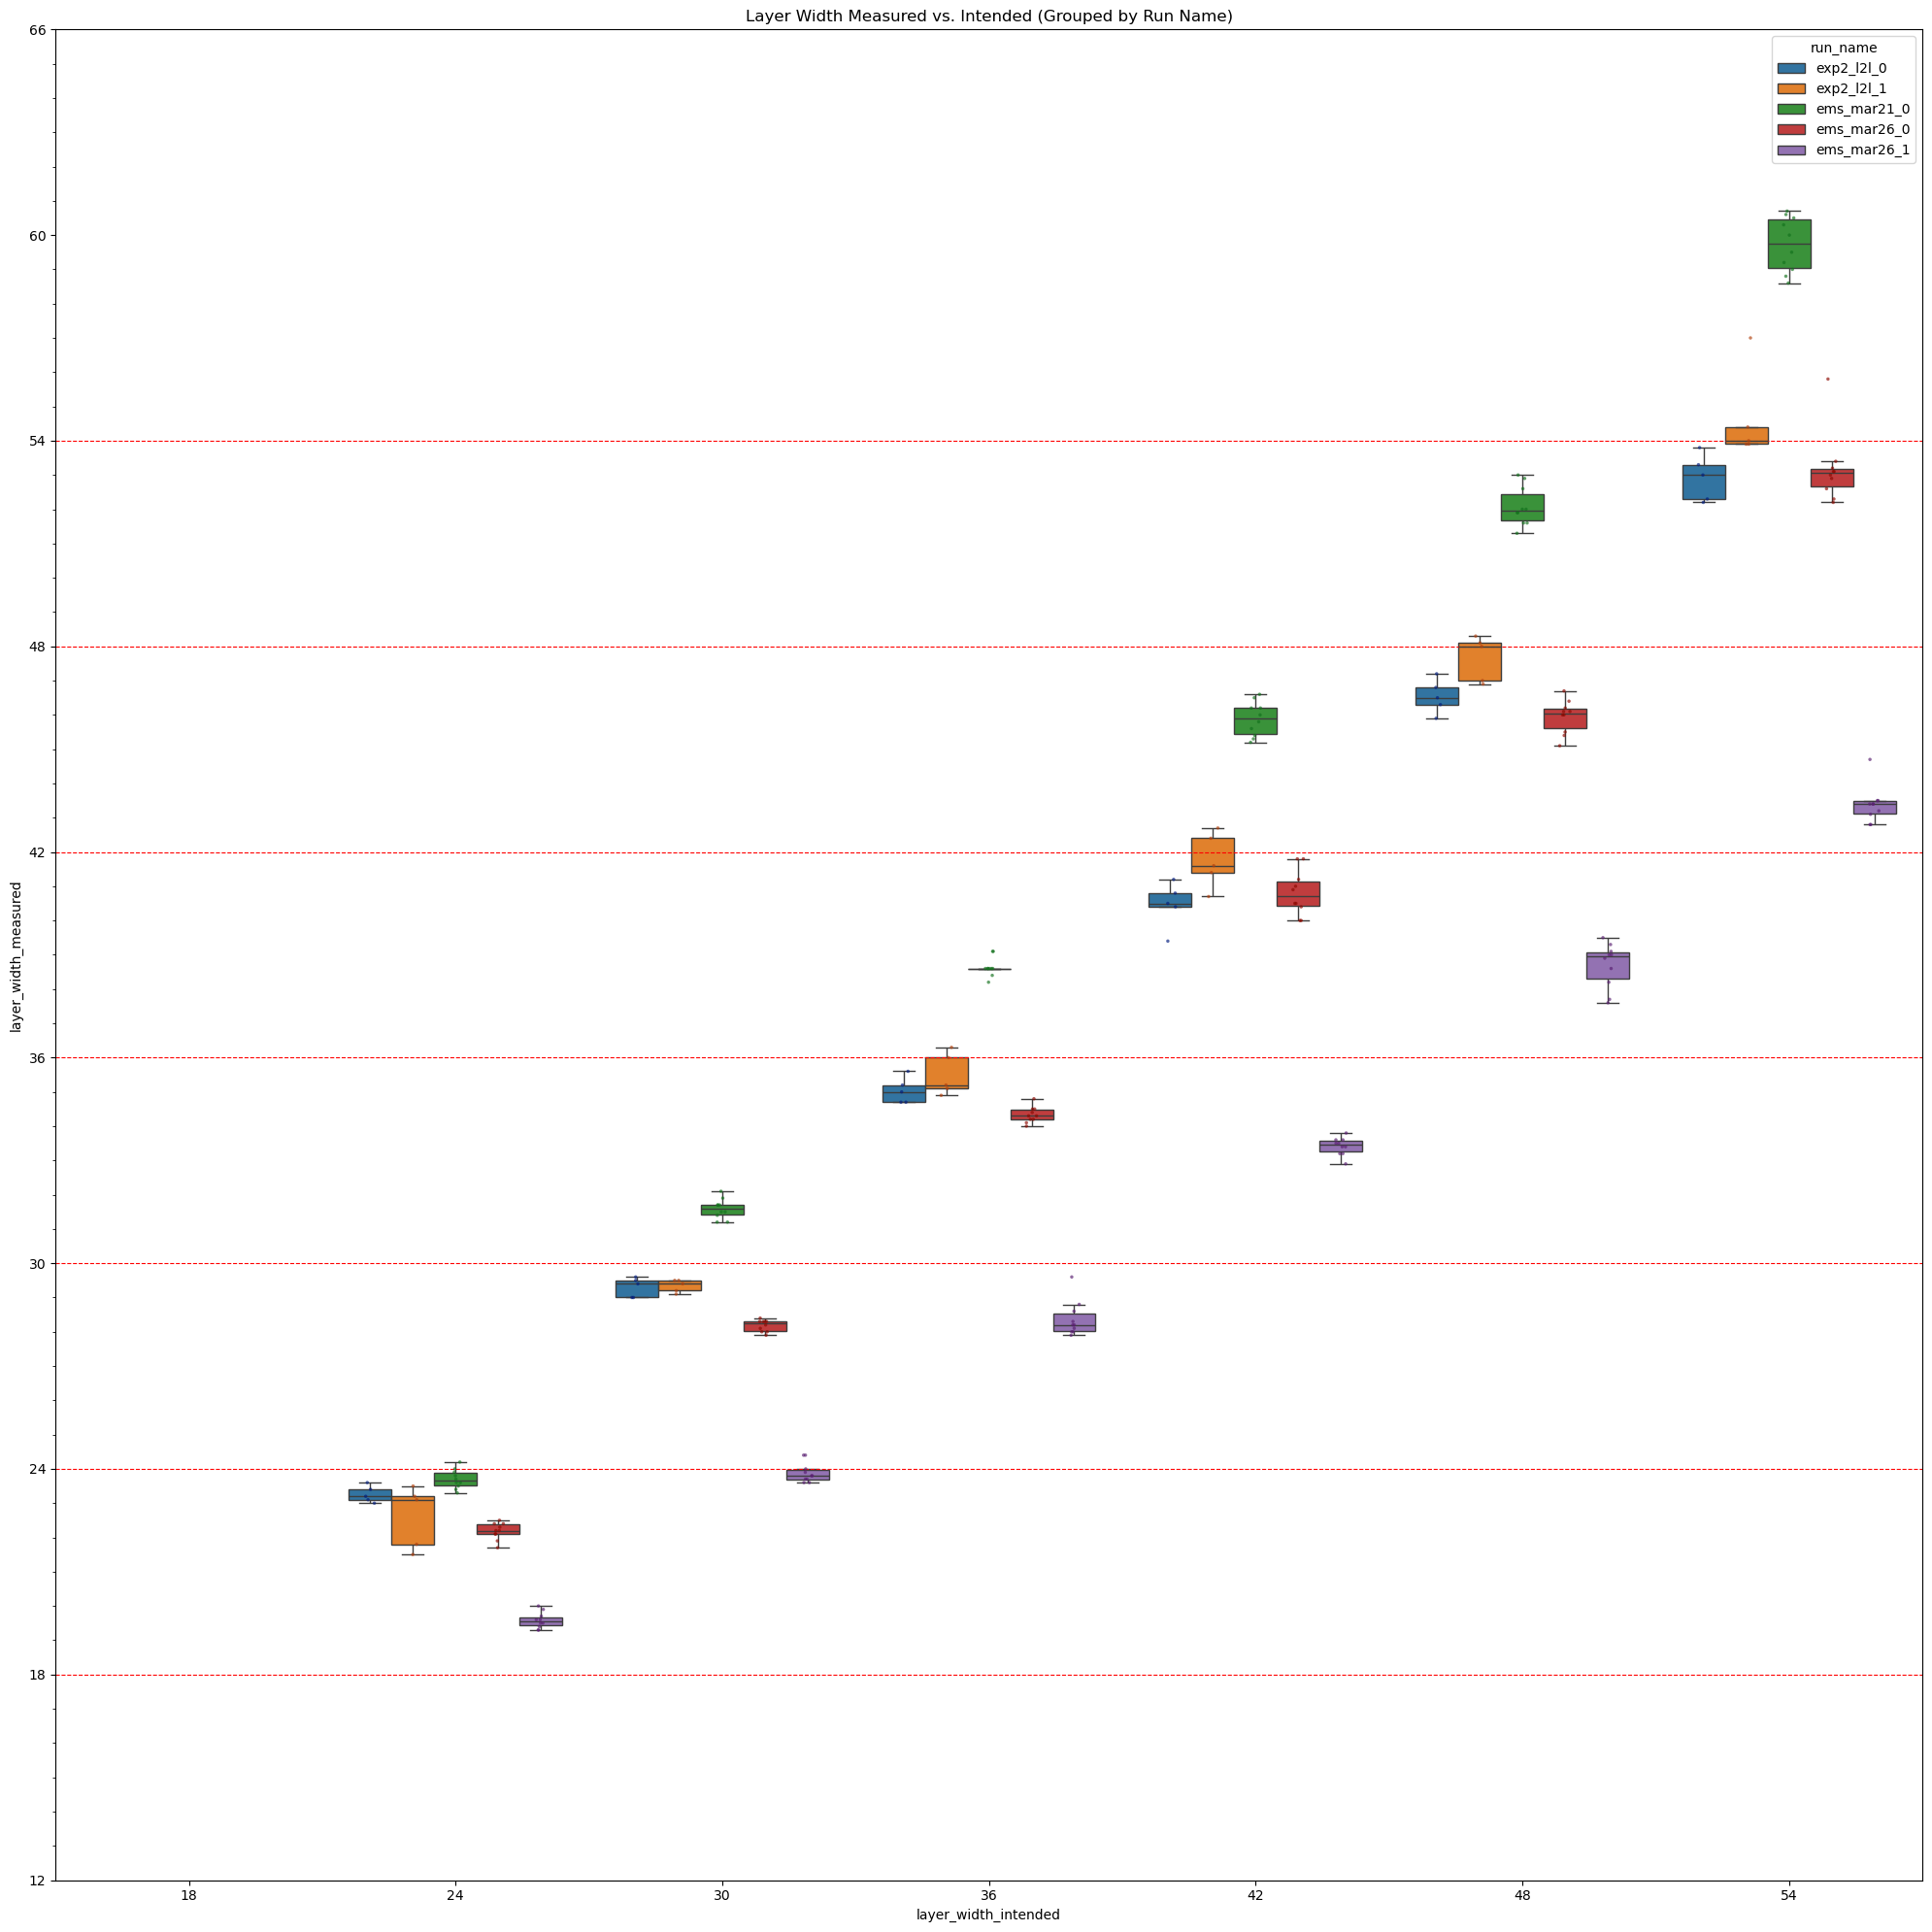

In [2]:
ems_df = pd.read_csv('data/EMS_serpentines.csv')

ems_df['run_name'] = ems_df['run_name'].replace({'210325_0': 'ems_mar21_0',
                                                 '260325_0': 'ems_mar26_0',
                                                 '260325_1': 'ems_mar26_1'})

l2l_df = pd.read_csv('data/experiment_2_merged.csv')
l2l_df = l2l_df[l2l_df['pallet'] == 'L2L']
l2l_df['run_name'] = 'exp2_l2l_' + l2l_df['nn-formula'].astype(str)
l2l_df.drop(['pallet', 'nn-formula', 'exp_speed'], axis=1, inplace=True)

cols = l2l_df.columns.tolist()
cols.insert(0, cols.pop(cols.index('run_name')))
l2l_df = l2l_df[cols]

merged_df = pd.concat([l2l_df, ems_df], axis=0, ignore_index=True)
merged_df.to_csv('data/EMS_merged.csv')

fig, ax = plt.subplots(figsize=(20, 20))

# Create a boxplot with run_name as the grouping variable.
sns.boxplot(
    data=merged_df,
    x='layer_width_intended',
    y='layer_width_measured',
    hue='run_name',
    showfliers=False,
    ax=ax
)

# Overlay individual data points.
# Note: We disable the legend for the stripplot so it doesn't duplicate the boxplot legend.
sns.stripplot(
    data=merged_df,
    x='layer_width_intended',
    y='layer_width_measured',
    hue='run_name',
    dodge=True,
    marker='.',
    palette='dark',
    ax=ax,
    alpha=0.66,
    legend=False,
)

# Draw red horizontal lines for each unique intended layer width (ensure 18 is included)
unique_intended = set(merged_df['layer_width_intended'].unique()).union({18})
for intended in unique_intended:
    ax.axhline(y=intended, color='red', linestyle='--', linewidth=0.8)

# Set y-axis grid lines: major ticks every 6 units, minor ticks every 1 unit.
ax.yaxis.set_major_locator(MultipleLocator(6))
ax.yaxis.set_minor_locator(MultipleLocator(1))
ax.set_ylim(12, 66)

# Set title and adjust layout.
ax.set_title("Layer Width Measured vs. Intended (Grouped by Run Name)")
plt.tight_layout()
plt.show()